In [1]:
import keras

num_words = 10_000  # keep the 10k most frequent tokens

(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=num_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1  #set specific indices of results[i] to 1s
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [3]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print(f"Dimensions de x_train partiel: {partial_x_train.shape}")
print(f"Dimensions de y_train partiel: {partial_y_train.shape}")
print(f"Dimensions de x_val: {x_val.shape}")
print(f"Dimensions de y_val: {y_val.shape}")
print(f"Dimensions de x_test: {x_test.shape}")
print(f"Dimensions de y_test: {y_test.shape}")

Dimensions de x_train partiel: (15000, 10000)
Dimensions de y_train partiel: (15000,)
Dimensions de x_val: (10000, 10000)
Dimensions de y_val: (10000,)
Dimensions de x_test: (25000, 10000)
Dimensions de y_test: (25000,)


In [6]:
from keras import models
from keras import layers
import keras

model = models.Sequential([
    keras.Input(shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Le modèle est maintenant construit et compilé. Passons à l'entraînement !

In [5]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.7629 - loss: 0.5352 - val_accuracy: 0.8560 - val_loss: 0.4086
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8930 - loss: 0.3250 - val_accuracy: 0.8855 - val_loss: 0.3114
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9181 - loss: 0.2432 - val_accuracy: 0.8634 - val_loss: 0.3300
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9371 - loss: 0.1972 - val_accuracy: 0.8861 - val_loss: 0.2852
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9469 - loss: 0.1653 - val_accuracy: 0.8880 - val_loss: 0.2788
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9564 - loss: 0.1399 - val_accuracy: 0.8845 - val_loss: 0.2997
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9613 - loss: 0.1216 - val_accuracy: 0.8855 - val_loss: 0.3049
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9698 - loss: 0.1016 - val_accuracy: 0.8836 - 

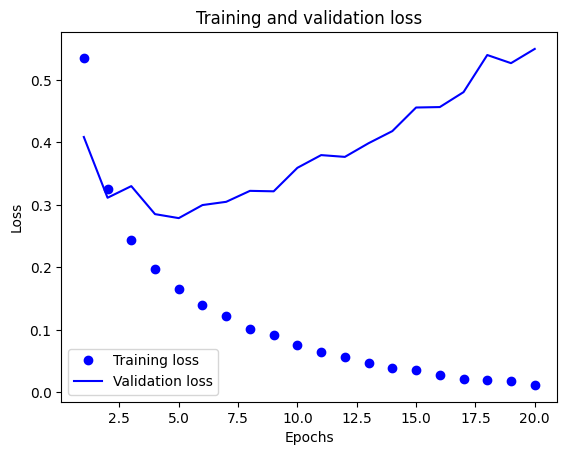

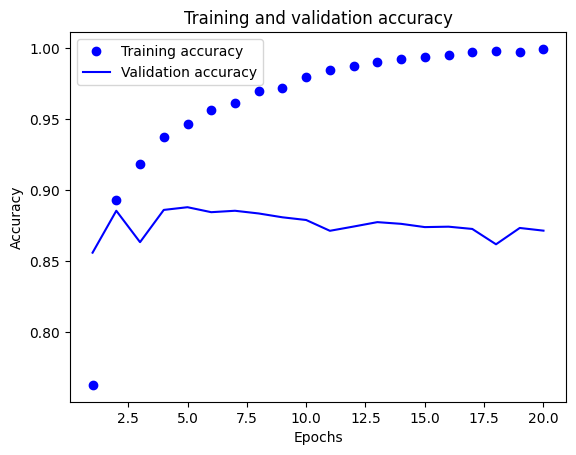

In [7]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()  # clear figure
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [8]:
model = models.Sequential([
    keras.Input(shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_optimal = model.fit(partial_x_train,
                            partial_y_train,
                            epochs=6, # Re-training with optimal epochs
                            batch_size=512,
                            validation_data=(x_val, y_val))

Epoch 1/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7753 - loss: 0.5367 - val_accuracy: 0.8631 - val_loss: 0.4072
Epoch 2/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8899 - loss: 0.3325 - val_accuracy: 0.8721 - val_loss: 0.3321
Epoch 3/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9177 - loss: 0.2472 - val_accuracy: 0.8886 - val_loss: 0.2859
Epoch 4/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9349 - loss: 0.1986 - val_accuracy: 0.8885 - val_loss: 0.2790
Epoch 5/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9455 - loss: 0.1669 - val_accuracy: 0.8878 - val_loss: 0.2789
Epoch 6/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9532 - loss: 0.1429 - val_accuracy: 0.8876 - val_loss: 0.2838


Le modèle a été réentraîné avec le nombre optimal d'époques. Évaluons maintenant ses performances sur l'ensemble de test.

In [9]:
results = model.evaluate(x_test, y_test)
print(f"Résultats du modèle sur l'ensemble de test : Loss = {results[0]:.4f}, Accuracy = {results[1]:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8797 - loss: 0.2997
Résultats du modèle sur l'ensemble de test : Loss = 0.2997, Accuracy = 0.8797


### Fonction de prédiction de sentiment

Nous allons maintenant écrire une fonction `predict_sentiment` qui prendra une nouvelle critique de film (en tant que chaîne de caractères) et retournera sa prédiction de sentiment (positive ou négative).

In [12]:
def predict_sentiment(review_text, word_index, model):
    # 1. Prétraitement de la critique:
    # Convertir le texte en une séquence d'entiers
    tokens = review_text.lower().split()
    sequence = []
    for word in tokens:
        # Obtenir l'indice du mot et appliquer un décalage de +3 pour correspondre à l'indexation du dataset IMDB
        # (0, 1, 2 sont réservés pour 'padding', 'start of sequence', 'unknown')
        if word in word_index and word_index[word] < num_words:
            sequence.append(word_index[word] + 3)

    # Vectoriser la séquence en une matrice one-hot
    # Note: La fonction `vectorize_sequences` attend une liste de séquences.
    # Nous devons donc envelopper notre séquence dans une liste.
    processed_review = vectorize_sequences([sequence])

    # 2. Faire une prédiction avec le modèle
    prediction = model.predict(processed_review)[0][0]

    # 3. Interpréter la prédiction
    if prediction >= 0.5:
        return f"Positif (Probabilité: {prediction:.2f})"
    else:
        return f"Négatif (Probabilité: {prediction:.2f})"


Pour utiliser la fonction `predict_sentiment`, nous avons besoin du dictionnaire `word_index` qui mappe les mots aux indices entiers. Keras fournit cette carte lors du chargement du jeu de données IMDB.

In [13]:
# Charger le dictionnaire word_index depuis le dataset IMDB
word_index = keras.datasets.imdb.get_word_index()

# Inverser le dictionnaire pour obtenir {index: word}
# (utile pour la visualisation, mais pas directement pour la prédiction ici)
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Exemples de critiques pour la prédiction
new_review_positive = "This movie was absolutely fantastic! The acting was superb, and the story was incredibly engaging. I highly recommend it."
new_review_negative = "Terrible movie. The plot was confusing, the acting was dreadful, and I wasted my time watching it. Avoid at all costs."
new_review_mixed = "It had some good moments, but overall it was a bit disappointing. The ending was weak."

print(f"Critique positive: {predict_sentiment(new_review_positive, word_index, model)}")
print(f"Critique négative: {predict_sentiment(new_review_negative, word_index, model)}")
print(f"Critique mitigée: {predict_sentiment(new_review_mixed, word_index, model)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Critique positive: Positif (Probabilité: 0.67)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Critique négative: Négatif (Probabilité: 0.17)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Critique mitigée: Positif (Probabilité: 0.67)
